In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

import mlflow

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

print(f"SHAP version: {shap.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print("Imports successful.")

SHAP version: 0.51.0
XGBoost version: 3.2.0
Imports successful.


In [2]:
# Cell 2 — Load processed data and rebuild tuned XGBoost
# We're rebuilding rather than loading from MLflow because reproducibility 
# is easier when the recruiter can clone, run, and verify the result themselves.

X_train = pd.read_csv('../data/processed/X_train_tree.csv')
X_test = pd.read_csv('../data/processed/X_test_tree.csv')
y_train = pd.read_csv('../data/processed/y_train_tree.csv')['target']
y_test = pd.read_csv('../data/processed/y_test.csv')['target_binary']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Re-tune XGBoost (this takes 2-3 min — same as yesterday)
# Note: n_jobs=1 on the inner estimator to avoid the Windows access violations 
# we hit yesterday with nested parallelism.
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1   # ← single-thread the inner XGBoost
    ),
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Re-tuning XGBoost...")
xgb_search.fit(X_train, y_train)

xgb_model = xgb_search.best_estimator_

print(f"\nBest CV ROC-AUC: {xgb_search.best_score_:.4f}")
print(f"\nTest set predictions:")
test_pred = xgb_model.predict(X_test)
test_proba = xgb_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
print(f"  Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"  Recall:   {recall_score(y_test, test_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, test_proba):.4f}")

Train: (262, 13), Test: (61, 13)
Re-tuning XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV ROC-AUC: 0.8868

Test set predictions:
  Accuracy: 0.8852
  Recall:   0.9286
  ROC-AUC:  0.9502


In [3]:
# Cell 3 — Initialize SHAP TreeExplainer on tuned XGBoost
# TreeExplainer: fast, exact, and the right choice for tree-based models.

explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the test set
# Output is an Explanation object containing values, base_values, and data
shap_values = explainer(X_test)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"  → 61 patients × 13 features = one SHAP value per (patient, feature) pair")
print(f"\nBase value (model's average prediction in log-odds): {explainer.expected_value:.4f}")
print(f"  → This is the baseline. SHAP values explain departures from this baseline.")
print(f"\nFirst patient's predicted probability: {xgb_model.predict_proba(X_test)[:1][:, 1][0]:.4f}")
print(f"First patient's SHAP values (one per feature):")
for feat, val in zip(X_test.columns, shap_values.values[0]):
    sign = '+' if val >= 0 else ''
    print(f"  {feat:12s}: {sign}{val:.4f}")

SHAP values shape: (61, 13)
  → 61 patients × 13 features = one SHAP value per (patient, feature) pair

Base value (model's average prediction in log-odds): 0.0025
  → This is the baseline. SHAP values explain departures from this baseline.

First patient's predicted probability: 0.2400
First patient's SHAP values (one per feature):
  age         : +0.1167
  trestbps    : +0.0000
  chol        : +0.0478
  thalach     : -0.2255
  oldpeak     : -0.1893
  sex         : +0.1399
  cp          : +0.5619
  fbs         : +0.0000
  restecg     : +0.0208
  exang       : -0.1532
  slope       : -0.2070
  ca          : -0.6551
  thal        : -0.6125


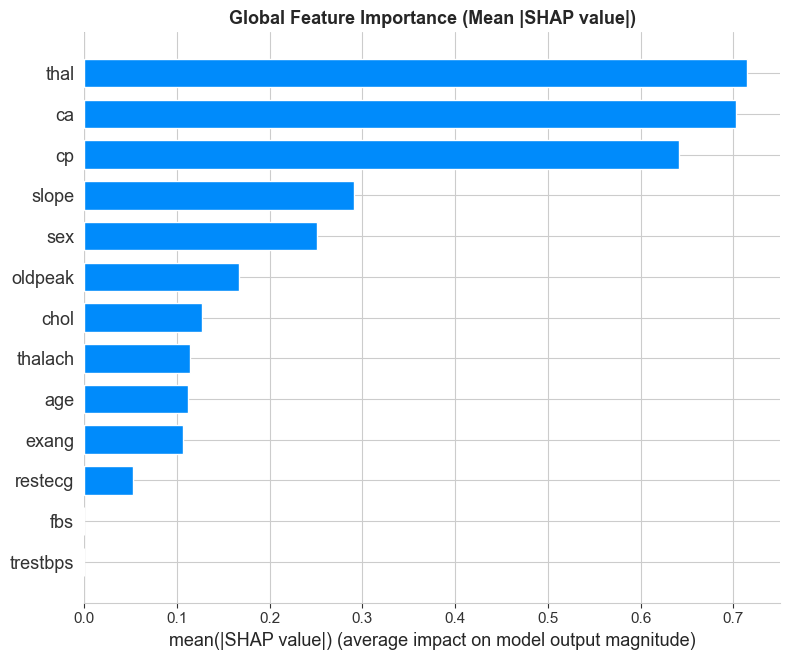

Saved: reports/figures/shap_global_bar.png


In [4]:
# Cell 4 — Global SHAP feature importance (bar plot)
# Mean absolute SHAP value across all 61 test patients = global feature importance.

os.makedirs('../reports/figures', exist_ok=True)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance (Mean |SHAP value|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_global_bar.png', dpi=120, bbox_inches='tight')
plt.show()

print("Saved: reports/figures/shap_global_bar.png")

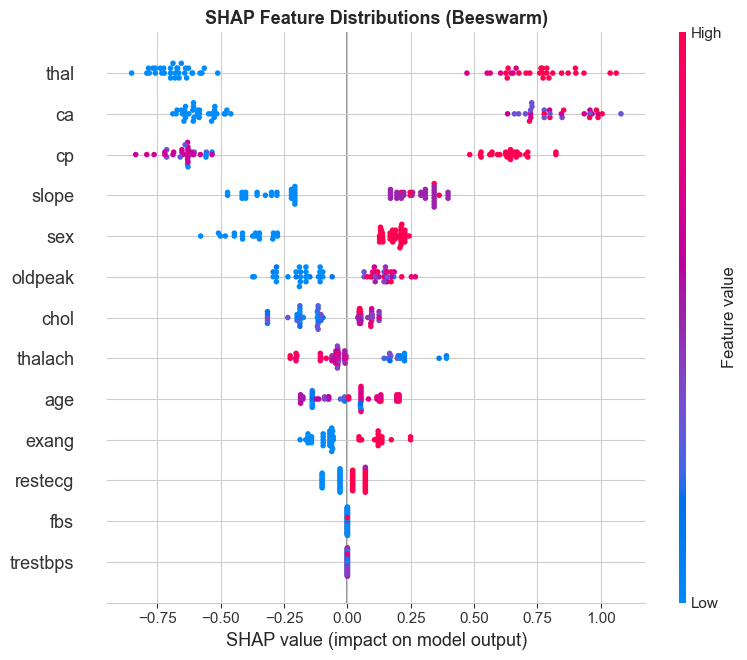

Saved: reports/figures/shap_beeswarm.png


In [5]:
# Cell 5 — Global SHAP beeswarm
# Each dot = one patient. Color = feature value (red=high, blue=low). 
# X-axis = SHAP value (push toward disease).
# Tells you not just which features matter, but HOW each value level pushes prediction.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='dot',  # default beeswarm
    show=False
)
plt.title('SHAP Feature Distributions (Beeswarm)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

print("Saved: reports/figures/shap_beeswarm.png")

Most-healthy prediction: patient #59, probability = 0.0555, true label = 0
Most-disease prediction: patient #51, probability = 0.9626, true label = 1

=== Most-healthy patient: waterfall ===


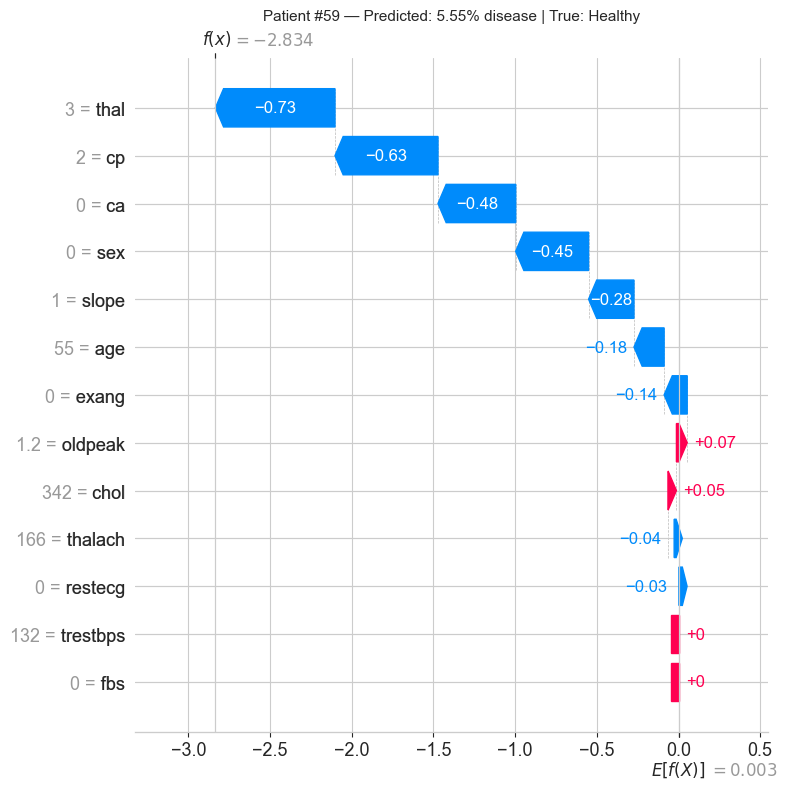


=== Most-disease patient: waterfall ===


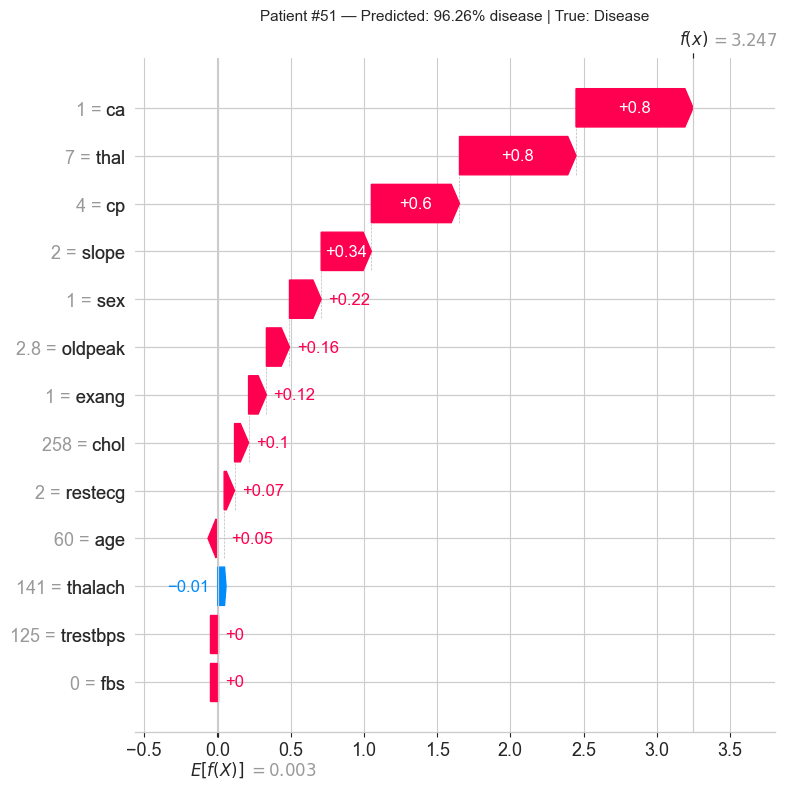


Saved both waterfall plots to reports/figures/


In [6]:
# Cell 6 — Per-patient force plots (waterfall view)
# Two patients: one the model confidently predicts as healthy, 
# one as disease. Show how features push prediction in each case.

import shap

# Find the test patients with the most extreme predictions
test_proba = xgb_model.predict_proba(X_test)[:, 1]

most_healthy_idx = np.argmin(test_proba)
most_disease_idx = np.argmax(test_proba)

print(f"Most-healthy prediction: patient #{most_healthy_idx}, probability = {test_proba[most_healthy_idx]:.4f}, true label = {y_test.iloc[most_healthy_idx]}")
print(f"Most-disease prediction: patient #{most_disease_idx}, probability = {test_proba[most_disease_idx]:.4f}, true label = {y_test.iloc[most_disease_idx]}")

# Waterfall plot for the most-healthy patient
print("\n=== Most-healthy patient: waterfall ===")
plt.figure()
shap.plots.waterfall(shap_values[most_healthy_idx], max_display=14, show=False)
plt.title(f'Patient #{most_healthy_idx} — Predicted: {test_proba[most_healthy_idx]:.2%} disease | True: {"Disease" if y_test.iloc[most_healthy_idx]==1 else "Healthy"}', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_healthy.png', dpi=120, bbox_inches='tight')
plt.show()

# Waterfall plot for the most-disease patient
print("\n=== Most-disease patient: waterfall ===")
plt.figure()
shap.plots.waterfall(shap_values[most_disease_idx], max_display=14, show=False)
plt.title(f'Patient #{most_disease_idx} — Predicted: {test_proba[most_disease_idx]:.2%} disease | True: {"Disease" if y_test.iloc[most_disease_idx]==1 else "Healthy"}', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_disease.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSaved both waterfall plots to reports/figures/")